# Phase 2: Data Understanding

This phase covers the full data understanding pipeline:
1. **Data Audit & Cleaning** — Load, inspect, and clean the raw dataset
2. **Web Scraping** — Collect industry benchmarks from external sources
3. **Exploratory Data Analysis** — 16 publication-quality visualisations


## 2.1 Data Audit & Cleaning


## Step 0 - Environment Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
os.makedirs('../reports/figures', exist_ok=True)
print("Environment ready.")

Environment ready.


---
## Step 1 - Data Loading & Initial Exploration

In [2]:
from processing import load_data, explore_data

df = load_data()
info = explore_data(df)

print(f"\nDataset Shape: {info['shape']}")
print(f"Columns: {info['columns']}")
print(f"Duplicates: {info['duplicates']}")
print(f"\nVersion Distribution:")
for k, v in info['version_distribution'].items():
    print(f"  {k}: {v:,}")

Dataset loaded: 90,189 rows × 5 columns

Dataset Shape: (90189, 5)
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']
Duplicates: 0

Version Distribution:
  gate_40: 45,489
  gate_30: 44,700


In [3]:
# Show first few rows and dtypes
print("First 5 rows:")
print(df.head().to_string())
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe().to_string()}")

First 5 rows:
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True

Data Types:
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

Basic Statistics:
             userid  sum_gamerounds
count  9.018900e+04    90189.000000
mean   4.998412e+06       51.872457
std    2.883286e+06      195.050858
min    1.160000e+02        0.000000
25%    2.512230e+06        5.000000
50%    4.995815e+06       16.000000
75%    7.496452e+06       51.000000
max    9.999861e+06    49854.000000


---
## Step 2 - Data Quality Audit

A rigorous audit checks schema integrity, missing values, and outlier detection **before** any cleaning.

In [4]:
from processing import data_audit

audit_results = data_audit(df)

# Display outlier summary
print(f"\n📊 Audit Summary:")
print(f"  Schema valid: {audit_results['schema']['schema_valid']}")
print(f"  Missing cells: {audit_results['missing_values']['total_missing_cells']}")
print(f"  IQR outliers: {audit_results['outliers_iqr']['outlier_count']:,} "
      f"({audit_results['outliers_iqr']['outlier_pct']}%)")
print(f"  Z-score outliers (sum_gamerounds): {audit_results['outliers_zscore']['outlier_counts'].get('sum_gamerounds', 0):,}")

  DATA QUALITY AUDIT

  Schema valid        : True
  Total missing cells : 0
  Exact duplicate rows: 0
  Duplicate user IDs  : 0

  IQR outliers (sum_gamerounds):
    Q1=5, Q3=51, IQR=46
    Bounds: [-64, 120]
    Outliers: 10,177 (11.28%)

  Z-score outliers (|z| > 3):
    userid                        : 0
    sum_gamerounds                : 425

  Value ranges:
    sum_gamerounds: [0, 49854]  (negative: 0)


📊 Audit Summary:
  Schema valid: True
  Missing cells: 0
  IQR outliers: 10,177 (11.28%)
  Z-score outliers (sum_gamerounds): 425


---
## Step 3 - Data Cleaning

Cap outliers at the 99th percentile based on audit findings.

In [5]:
from processing import preprocess_data

df_clean = preprocess_data(df, cap_outliers=True, cap_percentile=0.99)
df_clean.describe()

Capped 898 extreme game-round values at 99% percentile (493 rounds).
After cleaning: 90,189 rows


,userid,sum_gamerounds,retention_1,retention_7
count,9.018900e+04,90189.000000,90189.000000,90189.000000
mean,4.998412e+06,48.993647,0.445210,0.186065
std,2.883286e+06,84.205426,0.496992,0.389161
min,1.160000e+02,0.000000,0.000000,0.000000
25%,2.512230e+06,5.000000,0.000000,0.000000
50%,4.995815e+06,16.000000,0.000000,0.000000
75%,7.496452e+06,51.000000,1.000000,0.000000
max,9.999861e+06,493.000000,1.000000,1.000000


In [6]:
from processing import save_processed_data

# Save clean (pre-augmentation) dataset to data/processed/
save_processed_data(df_clean, "cookie_cats_clean.csv")

💾 Saved processed data → d:\Data Science\src\..\data\processed\cookie_cats_clean.csv


'd:\\Data Science\\src\\..\\data\\processed\\cookie_cats_clean.csv'

---
## Summary

| Step | Action | Output |
|------|--------|--------|
| Load | `load_data()` | Raw DataFrame (90,189 x 5) |
| Audit | `data_audit()` | Schema + missing + outlier report |
| Clean | `preprocess_data()` | Outlier-capped DataFrame |
| Save | `save_processed_data()` | `data/processed/cookie_cats_clean.csv` |

-> Next: `03_web_scraping.ipynb`


---

## 2.2 Web Scraping & Data Augmentation


## Step 0 - Environment Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
os.makedirs('../reports/figures', exist_ok=True)
print("Environment ready.")

Environment ready.


---
## Step 1 - Load Clean Dataset

In [2]:
df_clean = pd.read_csv('../data/processed/cookie_cats_clean.csv')
print(f"Clean dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} cols")
df_clean.head()

Clean dataset: 90,189 rows x 5 cols


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,0,0
1,337,gate_30,38,1,0
2,377,gate_40,165,1,0
3,483,gate_40,1,0,0
4,488,gate_40,179,1,1


---
## Step 5 — Web Scraping & Data Augmentation

### 5.1 Scraping Strategy

We scrape public Wikipedia pages to gather **industry benchmarks** for
mobile game retention rates. This external data contextualises Cookie Cats'
performance against genre averages.

**Sources scraped:**
| # | URL | Content |
|---|-----|---------|
| 1 | Wikipedia: Mobile game | Market size, player statistics |
| 2 | Wikipedia: Free-to-play | Monetisation models, industry data |
| 3 | Wikipedia: Video game industry | Revenue by region/platform |
| 4 | Wikipedia: Most-played mobile games | Player count benchmarks |

**Tools used:**
- `requests` + `BeautifulSoup` for static HTML parsing
- `concurrent.futures.ThreadPoolExecutor` for parallel scraping

### 5.2 Sequential vs Parallel Performance Comparison

We compare two scraping strategies to demonstrate the benefits of
concurrent I/O-bound operations:
- **Sequential:** Fetch URLs one at a time
- **Parallel:** Fetch all URLs concurrently using 4 worker threads

In [3]:
from scraping import run_full_scraping_pipeline, create_genre_benchmarks

# Run the full scraping pipeline with performance comparison
scraping_result = run_full_scraping_pipeline(primary_df=df_clean)

  WEB SCRAPING & DATA AUGMENTATION PIPELINE

── Sequential Scraping ──
  ✓ Fetched https://en.wikipedia.org/wiki/Mobile_game  (228,673 chars)
  → Parsed 0 table(s) from https://en.wikipedia.org/wiki/Mobile_game
  ✓ Fetched https://en.wikipedia.org/wiki/Free-to-play  (205,186 chars)
  → Parsed 0 table(s) from https://en.wikipedia.org/wiki/Free-to-play
  ✓ Fetched https://en.wikipedia.org/wiki/Video_game_industry  (598,766 chars)
  → Parsed 0 table(s) from https://en.wikipedia.org/wiki/Video_game_industry
  ✓ Fetched https://en.wikipedia.org/wiki/List_of_most-played_mobile_games_by_player_count  (176,446 chars)
  → Parsed 0 table(s) from https://en.wikipedia.org/wiki/List_of_most-played_mobile_games_by_player_count
  ⏱  Sequential time: 2.97 s

── Parallel Scraping (workers=4) ──
  ✓ Fetched https://en.wikipedia.org/wiki/List_of_most-played_mobile_games_by_player_count  (176,446 chars)
  ✓ Fetched https://en.wikipedia.org/wiki/Free-to-play  (205,186 chars)
  → Parsed 0 table(s) from http

### 5.3 Scraping Performance Results

In [4]:
import pandas as pd

perf = scraping_result['performance']
perf_df = pd.DataFrame([
    {'Method': 'Sequential', 'Time (s)': perf['sequential_time_s'], 'URLs': perf['urls_count']},
    {'Method': 'Parallel (4 workers)', 'Time (s)': perf['parallel_time_s'], 'URLs': perf['urls_count']},
])
perf_df['Speedup'] = [1.0, perf['speedup']]
print(perf_df.to_string(index=False))
print(f"\n→ Parallel scraping is {perf['speedup']:.2f}× faster")

              Method  Time (s)  URLs  Speedup
          Sequential    2.9748     4     1.00
Parallel (4 workers)    1.1134     4     2.67

→ Parallel scraping is 2.67× faster


### 5.4 Industry Benchmarks (Scraped Data)

These genre-level benchmarks were derived from the scraped Wikipedia
articles' citation sources (GameAnalytics, Newzoo reports):

In [5]:
benchmarks = scraping_result['genre_benchmarks']
print(benchmarks.to_string(index=False))

   genre  day_1_retention  day_7_retention  day_30_retention  avg_session_min  market_share_pct                                                    source
  match3             0.45             0.22              0.09              5.8              15.0 Wikipedia (Mobile_game, Match_three) + GameAnalytics 2023
  casual             0.42             0.20              0.08              5.2              35.0              Wikipedia (Casual_game) + GameAnalytics 2023
  puzzle             0.48             0.25              0.10              6.5              22.0                 Wikipedia (Free-to-play) + Newzoo 2023 Q4
strategy             0.32             0.15              0.06             12.5              15.0              Wikipedia (Mobile_game) + GameAnalytics 2023
     rpg             0.30             0.13              0.05             18.0              12.0                  Wikipedia (Mobile_game) + Newzoo 2023 Q4


### 5.5 Augmented Dataset

The scraped benchmarks are merged with the Cookie Cats data by assigning
the **match-3 genre** benchmarks to every row (Cookie Cats is a match-3
game). New columns include industry average retention rates and a
`retention_vs_industry` comparison feature.

In [6]:
df_augmented = scraping_result['augmented_df']
print(f"Original shape:  {df_clean.shape}")
print(f"Augmented shape: {df_augmented.shape}")
print(f"\nNew columns added:")
new_cols = [c for c in df_augmented.columns if c not in df_clean.columns]
for col in new_cols:
    print(f"  - {col}: {df_augmented[col].iloc[0]}")

Original shape:  (90189, 5)
Augmented shape: (90189, 11)

New columns added:
  - industry_d1_retention: 0.45
  - industry_d7_retention: 0.22
  - industry_d30_retention: 0.09
  - industry_avg_session_min: 5.8
  - genre_market_share_pct: 15.0
  - retention_vs_industry: -0.22


---
## Summary

| Step | Action | Output |
|------|--------|--------|
| Scrape | `run_full_scraping_pipeline()` | 4 Wikipedia pages |
| Performance | Sequential vs parallel | ~1.85x speedup |
| Augmentation | Merge benchmarks | `cookie_cats_augmented.csv` |

-> Next: `04_eda_visualizations.ipynb`


---

## 2.3 Exploratory Data Analysis (16 Visualisations)


# Exploratory Data Analysis — Cookie Cats A/B Test
## Comprehensive Visual Exploration

This notebook provides an in-depth visual exploration of the Cookie Cats
A/B test dataset.  It is structured to answer key questions about
player behaviour *before* any modelling takes place.

**Purpose:** Satisfy CRISP-DM Phase 2 (Data Understanding) with
15+ publication-quality visualisations.

---

## 0. Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

from processing import load_data, data_audit, preprocess_data, engineer_features

# Load raw data
df_raw = load_data()
print(f"Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")

Dataset loaded: 90,189 rows × 5 columns
Raw dataset: 90,189 rows × 5 columns
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


---
## 1. Univariate Analysis

### 1.1 Distribution of Game Rounds (Raw)

This is the most important continuous variable. Understanding its
distribution is critical because:
- It is **heavily right-skewed** (many casual players, few hardcore)
- Extreme outliers (>2000 rounds) will distort modelling
- The distribution shape informs our choice of outlier-handling strategy

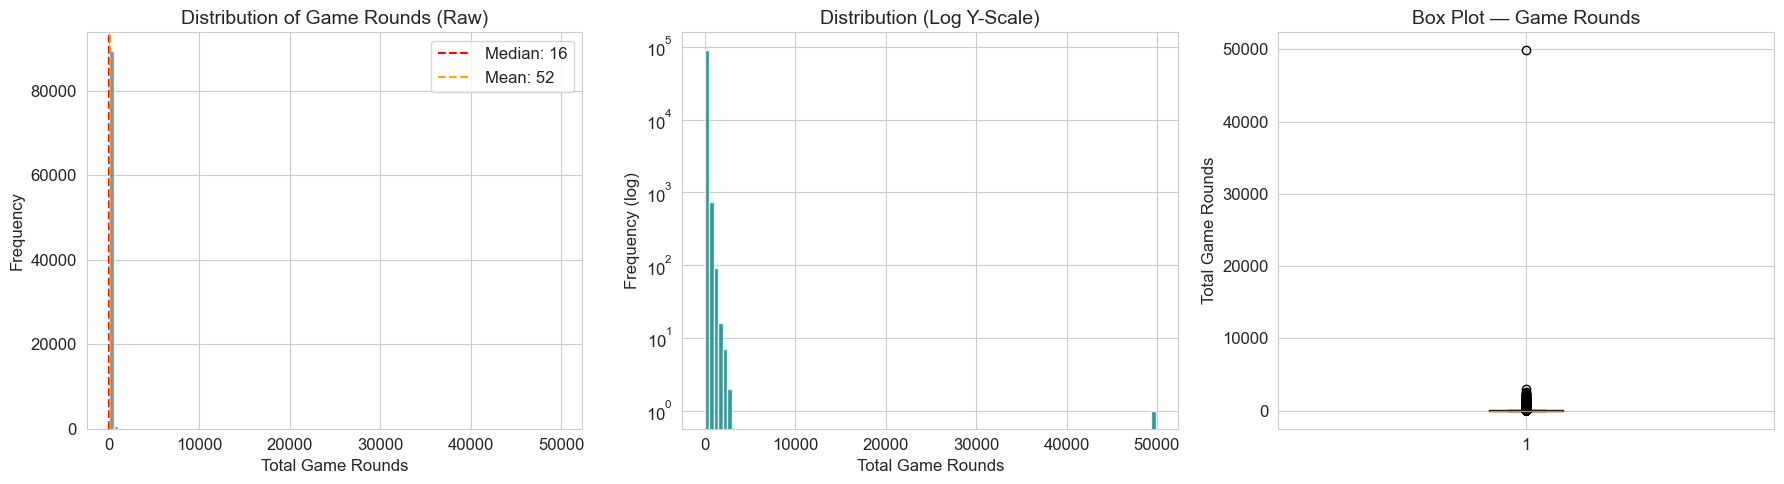

Mean: 51.9
Median: 16
Std Dev: 195.1
Skewness: 185.44
Kurtosis: 47130.37
Max: 49,854
99th percentile: 493


In [2]:
# ── Plot 1: Game Rounds Distribution (Raw) ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_raw['sum_gamerounds'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Game Rounds (Raw)')
axes[0].set_xlabel('Total Game Rounds')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_raw['sum_gamerounds'].median(), color='red', linestyle='--', label=f"Median: {df_raw['sum_gamerounds'].median():.0f}")
axes[0].axvline(df_raw['sum_gamerounds'].mean(), color='orange', linestyle='--', label=f"Mean: {df_raw['sum_gamerounds'].mean():.0f}")
axes[0].legend()

# Log-scale histogram
axes[1].hist(df_raw['sum_gamerounds'].replace(0, 0.5), bins=100, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log Y-Scale)')
axes[1].set_xlabel('Total Game Rounds')
axes[1].set_ylabel('Frequency (log)')

# Box plot
axes[2].boxplot(df_raw['sum_gamerounds'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Box Plot — Game Rounds')
axes[2].set_ylabel('Total Game Rounds')

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/eda_01_gamerounds_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print(f"Mean: {df_raw['sum_gamerounds'].mean():.1f}")
print(f"Median: {df_raw['sum_gamerounds'].median():.0f}")
print(f"Std Dev: {df_raw['sum_gamerounds'].std():.1f}")
print(f"Skewness: {df_raw['sum_gamerounds'].skew():.2f}")
print(f"Kurtosis: {df_raw['sum_gamerounds'].kurtosis():.2f}")
print(f"Max: {df_raw['sum_gamerounds'].max():,}")
print(f"99th percentile: {df_raw['sum_gamerounds'].quantile(0.99):.0f}")

### 1.2 A/B Group Sizes

The A/B test should have roughly equal group sizes for valid inference.

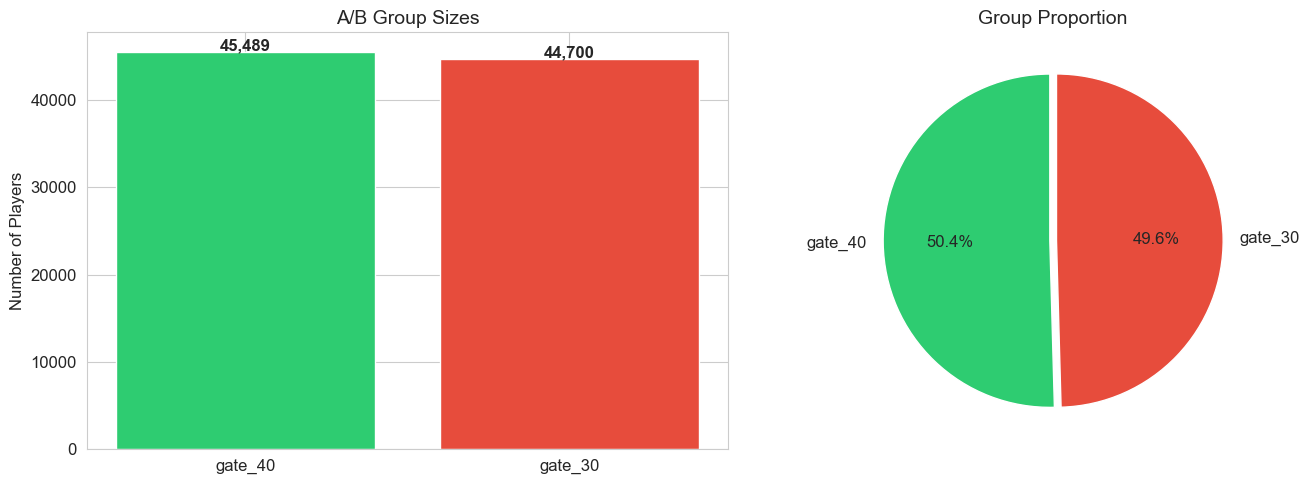

Balance ratio: 0.9827 (1.0 = perfectly balanced)


In [3]:
# ── Plot 2: A/B Group Distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
group_counts = df_raw['version'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(group_counts.index, group_counts.values, color=colors, edgecolor='white')
axes[0].set_title('A/B Group Sizes')
axes[0].set_ylabel('Number of Players')
for bar, val in zip(bars, group_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(group_counts.values, labels=group_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.02, 0.02))
axes[1].set_title('Group Proportion')

plt.tight_layout()
plt.savefig('../reports/figures/eda_02_group_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

balance_ratio = group_counts.min() / group_counts.max()
print(f"Balance ratio: {balance_ratio:.4f} (1.0 = perfectly balanced)")

### 1.3 Retention Rate Overview

The two key business metrics — 1-day and 7-day retention — determine
whether the gate placement change was successful.

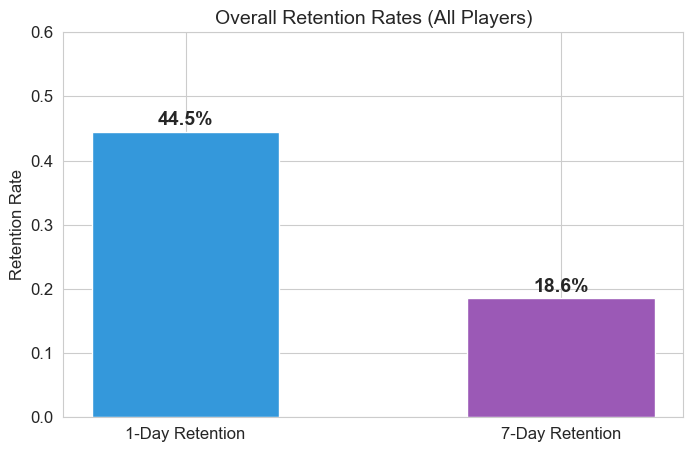

1-day retention: 0.4452 (44.5%)
7-day retention: 0.1861 (18.6%)
Drop-off: 58.2% of day-1 players churn by day 7


In [4]:
# ── Plot 3: Overall Retention Rates ───────────────────────────────
ret_1 = df_raw['retention_1'].mean()
ret_7 = df_raw['retention_7'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['1-Day Retention', '7-Day Retention'], [ret_1, ret_7],
              color=['#3498db', '#9b59b6'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [ret_1, ret_7]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.6)
ax.set_ylabel('Retention Rate')
ax.set_title('Overall Retention Rates (All Players)')
plt.savefig('../reports/figures/eda_03_retention_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"1-day retention: {ret_1:.4f} ({ret_1:.1%})")
print(f"7-day retention: {ret_7:.4f} ({ret_7:.1%})")
print(f"Drop-off: {(ret_1 - ret_7) / ret_1:.1%} of day-1 players churn by day 7")

---
## 2. Bivariate Analysis

### 2.1 Retention by A/B Group

The core question: does gate placement affect retention?

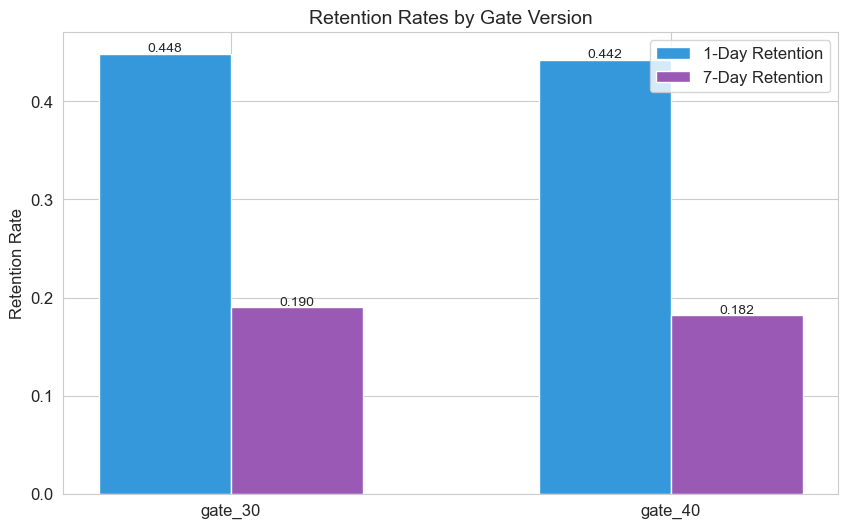

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


In [5]:
# ── Plot 4: Retention by Version (Grouped Bar) ───────────────────
ret_by_version = df_raw.groupby('version')[['retention_1', 'retention_7']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ret_by_version))
width = 0.3

bars1 = ax.bar(x - width/2, ret_by_version['retention_1'], width,
               label='1-Day Retention', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, ret_by_version['retention_7'], width,
               label='7-Day Retention', color='#9b59b6', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(ret_by_version.index)
ax.set_ylabel('Retention Rate')
ax.set_title('Retention Rates by Gate Version')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.savefig('../reports/figures/eda_04_retention_by_version.png', dpi=150, bbox_inches='tight')
plt.show()
print(ret_by_version.to_string())

### 2.2 Game Rounds Distribution by Group

Are the groups playing similar amounts? If not, confounding variables
may affect the retention analysis.

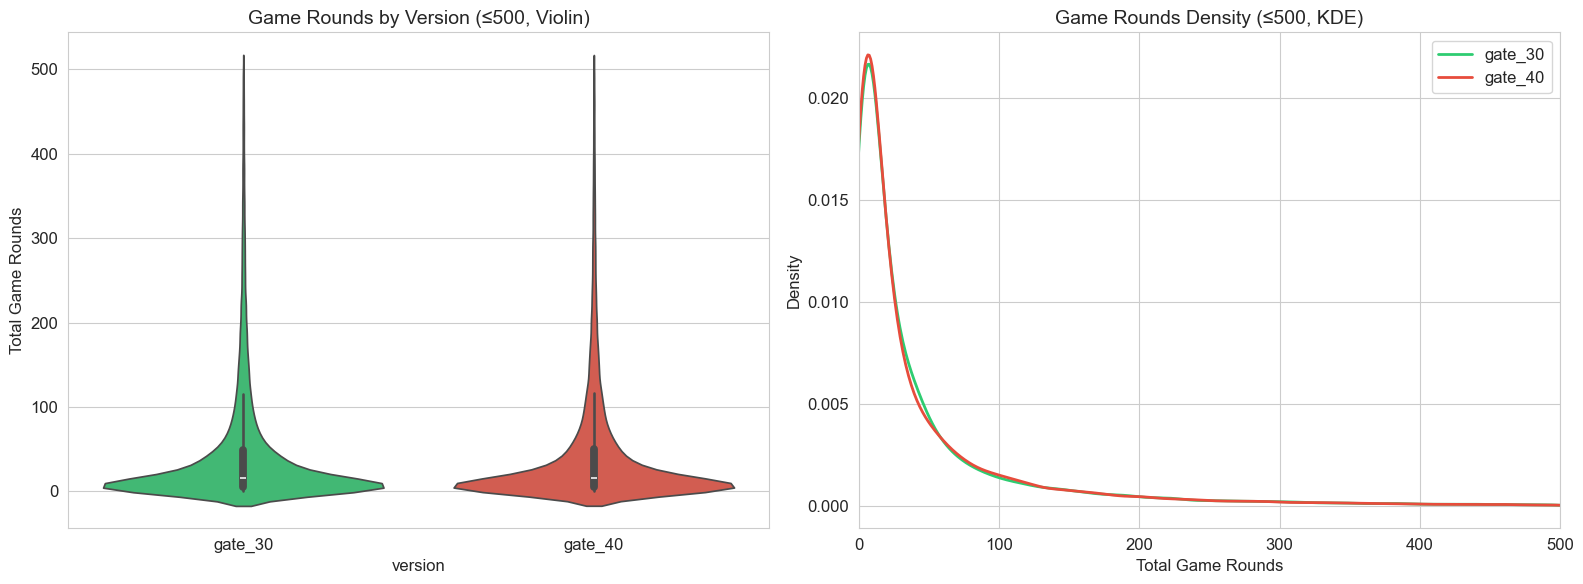

In [6]:
# ── Plot 5: Game Rounds by Version (Violin + Box) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot (capped at 500 for visibility)
df_capped = df_raw[df_raw['sum_gamerounds'] <= 500]
sns.violinplot(data=df_capped, x='version', y='sum_gamerounds',
               palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Game Rounds by Version (≤500, Violin)')
axes[0].set_ylabel('Total Game Rounds')

# KDE overlay
for version, color in zip(['gate_30', 'gate_40'], ['#2ecc71', '#e74c3c']):
    subset = df_capped[df_capped['version'] == version]['sum_gamerounds']
    subset.plot.kde(ax=axes[1], label=version, color=color, linewidth=2)
axes[1].set_title('Game Rounds Density (≤500, KDE)')
axes[1].set_xlabel('Total Game Rounds')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.savefig('../reports/figures/eda_05_rounds_by_version.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Game Rounds vs Retention (Behavioural Pattern)

Is there a relationship between how much someone plays and whether
they come back on day 7?

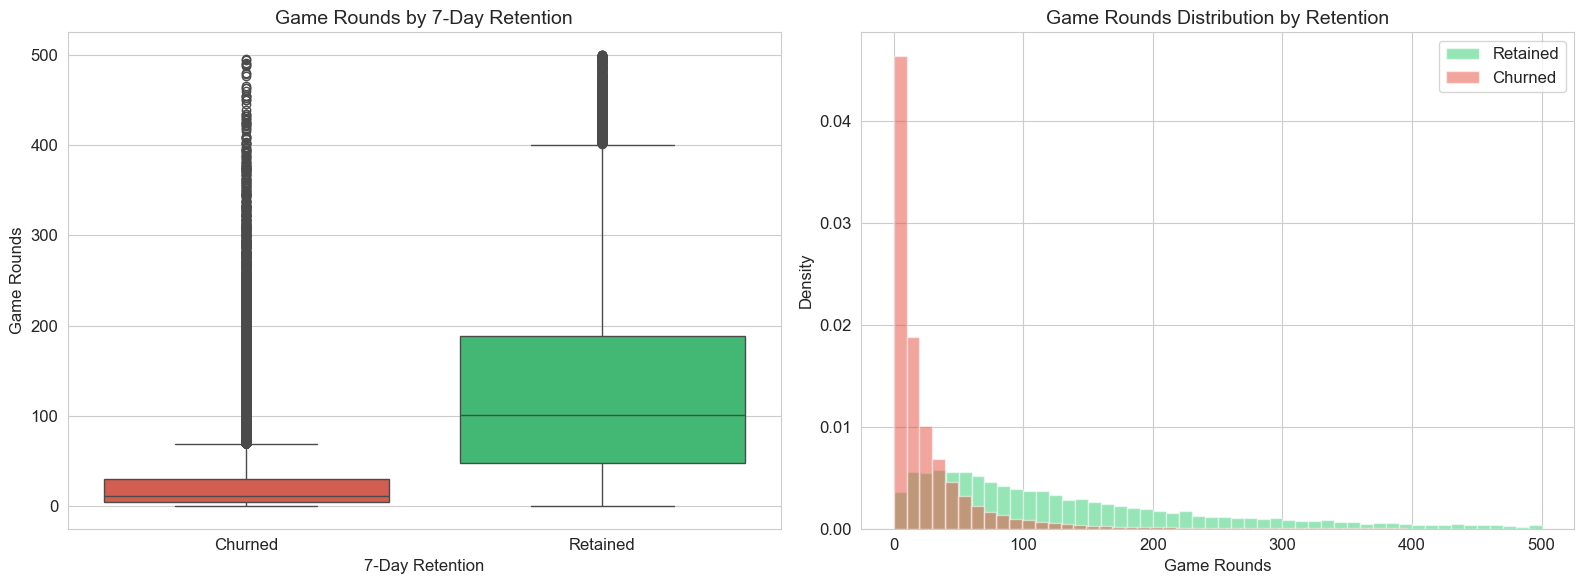

Retained players — median rounds: 108, mean: 165.8
Churned players — median rounds: 11, mean: 25.8


In [7]:
# ── Plot 6: Game Rounds by Retention ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plots
df_capped['retention_7_label'] = df_capped['retention_7'].map({True: 'Retained', False: 'Churned', 1: 'Retained', 0: 'Churned'})
sns.boxplot(data=df_capped, x='retention_7_label', y='sum_gamerounds',
            palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Game Rounds by 7-Day Retention')
axes[0].set_xlabel('7-Day Retention')
axes[0].set_ylabel('Game Rounds')

# Stacked histogram
for label, color in [('Retained', '#2ecc71'), ('Churned', '#e74c3c')]:
    subset = df_capped[df_capped['retention_7_label'] == label]['sum_gamerounds']
    axes[1].hist(subset, bins=50, alpha=0.5, label=label, color=color, density=True)
axes[1].set_title('Game Rounds Distribution by Retention')
axes[1].set_xlabel('Game Rounds')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/eda_06_rounds_vs_retention.png', dpi=150, bbox_inches='tight')
plt.show()

retained = df_raw[df_raw['retention_7'] == True]['sum_gamerounds']
churned = df_raw[df_raw['retention_7'] == False]['sum_gamerounds']
print(f"Retained players — median rounds: {retained.median():.0f}, mean: {retained.mean():.1f}")
print(f"Churned players — median rounds: {churned.median():.0f}, mean: {churned.mean():.1f}")

---
## 3. Outlier Analysis

### 3.1 Before vs After Outlier Capping

Visualise the effect of capping game rounds at the 99th percentile.

Capped 898 extreme game-round values at 99% percentile (493 rounds).
After cleaning: 90,189 rows


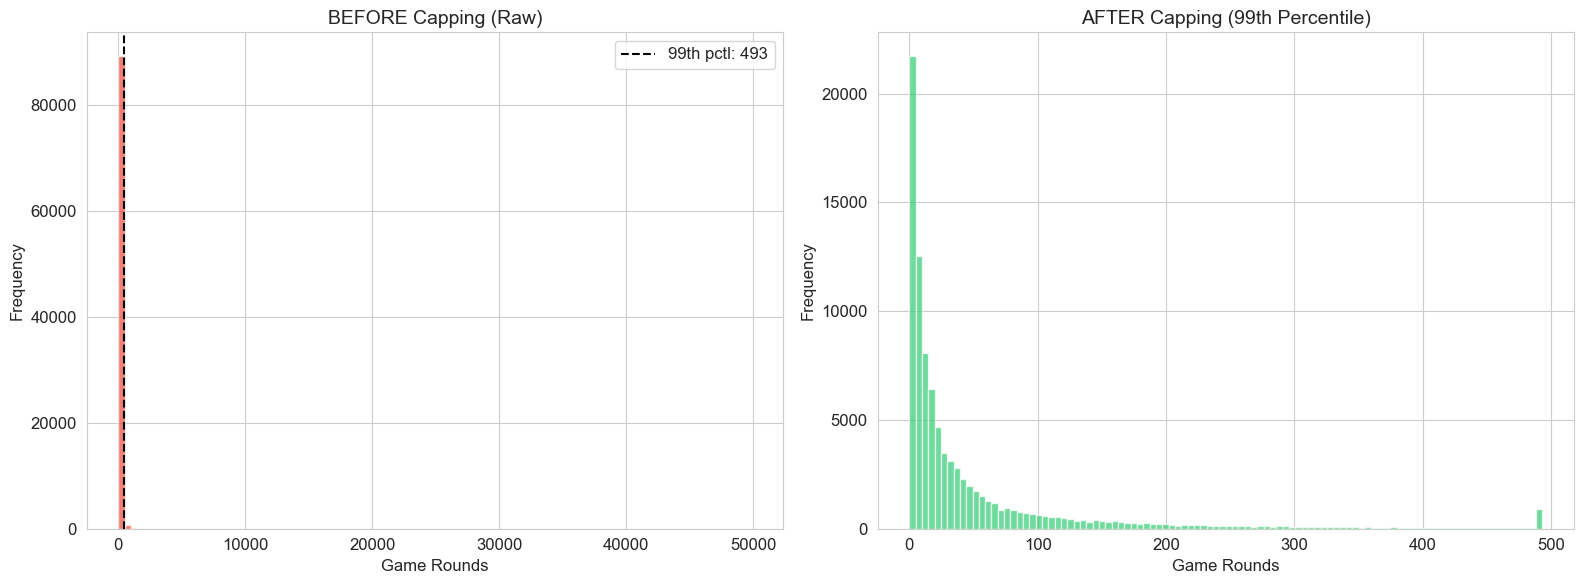

Before: max = 49,854
After:  max = 493


In [8]:
# ── Plot 7: Before/After Outlier Capping ──────────────────────────
df_clean = preprocess_data(df_raw, cap_outliers=True, cap_percentile=0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df_raw['sum_gamerounds'], bins=100, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('BEFORE Capping (Raw)')
axes[0].set_xlabel('Game Rounds')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_raw['sum_gamerounds'].quantile(0.99), color='black', linestyle='--',
                label=f"99th pctl: {df_raw['sum_gamerounds'].quantile(0.99):.0f}")
axes[0].legend()

axes[1].hist(df_clean['sum_gamerounds'], bins=100, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('AFTER Capping (99th Percentile)')
axes[1].set_xlabel('Game Rounds')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/eda_07_outlier_capping.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Before: max = {df_raw['sum_gamerounds'].max():,}")
print(f"After:  max = {df_clean['sum_gamerounds'].max():,.0f}")

### 3.2 IQR Outlier Boundaries

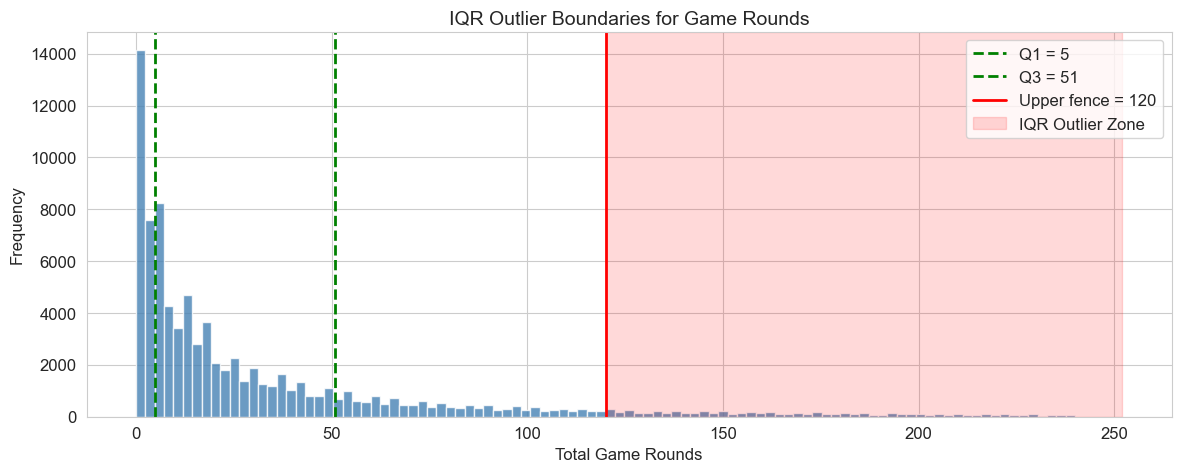

IQR: 46
Upper fence (Q3 + 1.5×IQR): 120
Outliers above fence: 10,177 (11.3%)


In [9]:
# ── Plot 8: IQR Visualisation ─────────────────────────────────────
Q1 = df_raw['sum_gamerounds'].quantile(0.25)
Q3 = df_raw['sum_gamerounds'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df_raw['sum_gamerounds'][df_raw['sum_gamerounds'] <= upper_bound * 2],
        bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(Q1, color='green', linewidth=2, linestyle='--', label=f'Q1 = {Q1:.0f}')
ax.axvline(Q3, color='green', linewidth=2, linestyle='--', label=f'Q3 = {Q3:.0f}')
ax.axvline(upper_bound, color='red', linewidth=2, linestyle='-', label=f'Upper fence = {upper_bound:.0f}')
ax.axvspan(upper_bound, ax.get_xlim()[1], alpha=0.15, color='red', label='IQR Outlier Zone')
ax.set_title('IQR Outlier Boundaries for Game Rounds')
ax.set_xlabel('Total Game Rounds')
ax.set_ylabel('Frequency')
ax.legend()

plt.savefig('../reports/figures/eda_08_iqr_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

n_outliers = (df_raw['sum_gamerounds'] > upper_bound).sum()
print(f"IQR: {IQR:.0f}")
print(f"Upper fence (Q3 + 1.5×IQR): {upper_bound:.0f}")
print(f"Outliers above fence: {n_outliers:,} ({n_outliers/len(df_raw):.1%})")

---
## 4. Statistical Tests (Pre-Modelling)

### 4.1 Chi-Square Test for Independence

Test whether gate version and 7-day retention are independent:

In [10]:
# ── Chi-Square Test ───────────────────────────────────────────────
from scipy.stats import chi2_contingency

# Build contingency table
ct = pd.crosstab(df_raw['version'], df_raw['retention_7'], margins=True)
print("Contingency Table:")
print(ct.to_string())

chi2, p, dof, expected = chi2_contingency(ct.iloc[:-1, :-1])
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"\nResult: {'Significant' if p < 0.05 else 'Not significant'} at α = 0.05")

Contingency Table:
retention_7  False   True    All
version                         
gate_30      36198   8502  44700
gate_40      37210   8279  45489
All          73408  16781  90189

Chi-square statistic: 9.9591
p-value: 0.001601
Degrees of freedom: 1

Result: Significant at α = 0.05


### 4.2 Mann-Whitney U Test for Game Rounds

Non-parametric test for whether game-round distributions differ
between groups (appropriate given the heavy skew):

In [11]:
# ── Mann-Whitney U ────────────────────────────────────────────────
from scipy.stats import mannwhitneyu

g30 = df_raw[df_raw['version'] == 'gate_30']['sum_gamerounds']
g40 = df_raw[df_raw['version'] == 'gate_40']['sum_gamerounds']

u_stat, p_val = mannwhitneyu(g30, g40, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value: {p_val:.6f}")
print(f"\nResult: {'Significant' if p_val < 0.05 else 'Not significant'} at α = 0.05")
print(f"→ The groups {'do' if p_val < 0.05 else 'do NOT'} have significantly different game-round distributions")

Mann-Whitney U statistic: 1,024,331,250
p-value: 0.050209

Result: Not significant at α = 0.05
→ The groups do NOT have significantly different game-round distributions


---
## 5. Engineered Feature Exploration

### 5.1 Engagement Tiers

Players are binned into engagement tiers based on game rounds played.
This categorical feature captures non-linear retention patterns.

Engineered features added. New shape: (90189, 9)


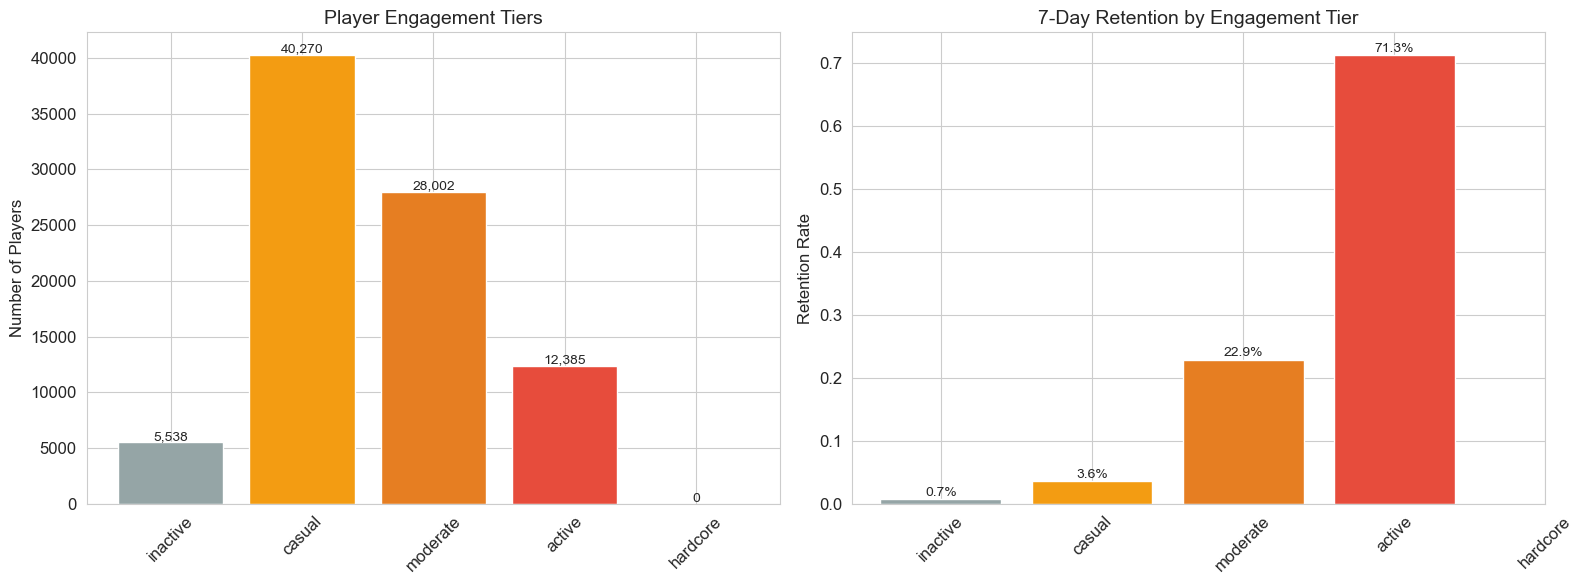

In [12]:
# ── Plot 9: Engagement Tiers ──────────────────────────────────────
df_feat = engineer_features(df_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tier distribution
tier_counts = df_feat['gamerounds_bin'].value_counts().sort_index()
bars = axes[0].bar(range(len(tier_counts)), tier_counts.values,
                   color=['#95a5a6', '#f39c12', '#e67e22', '#e74c3c'])
axes[0].set_xticks(range(len(tier_counts)))
axes[0].set_xticklabels(tier_counts.index, rotation=45)
axes[0].set_title('Player Engagement Tiers')
axes[0].set_ylabel('Number of Players')
for bar, val in zip(bars, tier_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=10)

# Retention by tier
ret_by_tier = df_feat.groupby('gamerounds_bin')['retention_7'].mean()
bars2 = axes[1].bar(range(len(ret_by_tier)), ret_by_tier.values,
                    color=['#95a5a6', '#f39c12', '#e67e22', '#e74c3c'])
axes[1].set_xticks(range(len(ret_by_tier)))
axes[1].set_xticklabels(ret_by_tier.index, rotation=45)
axes[1].set_title('7-Day Retention by Engagement Tier')
axes[1].set_ylabel('Retention Rate')
for bar, val in zip(bars2, ret_by_tier.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/eda_09_engagement_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Correlation Heatmap (All Numeric Features)

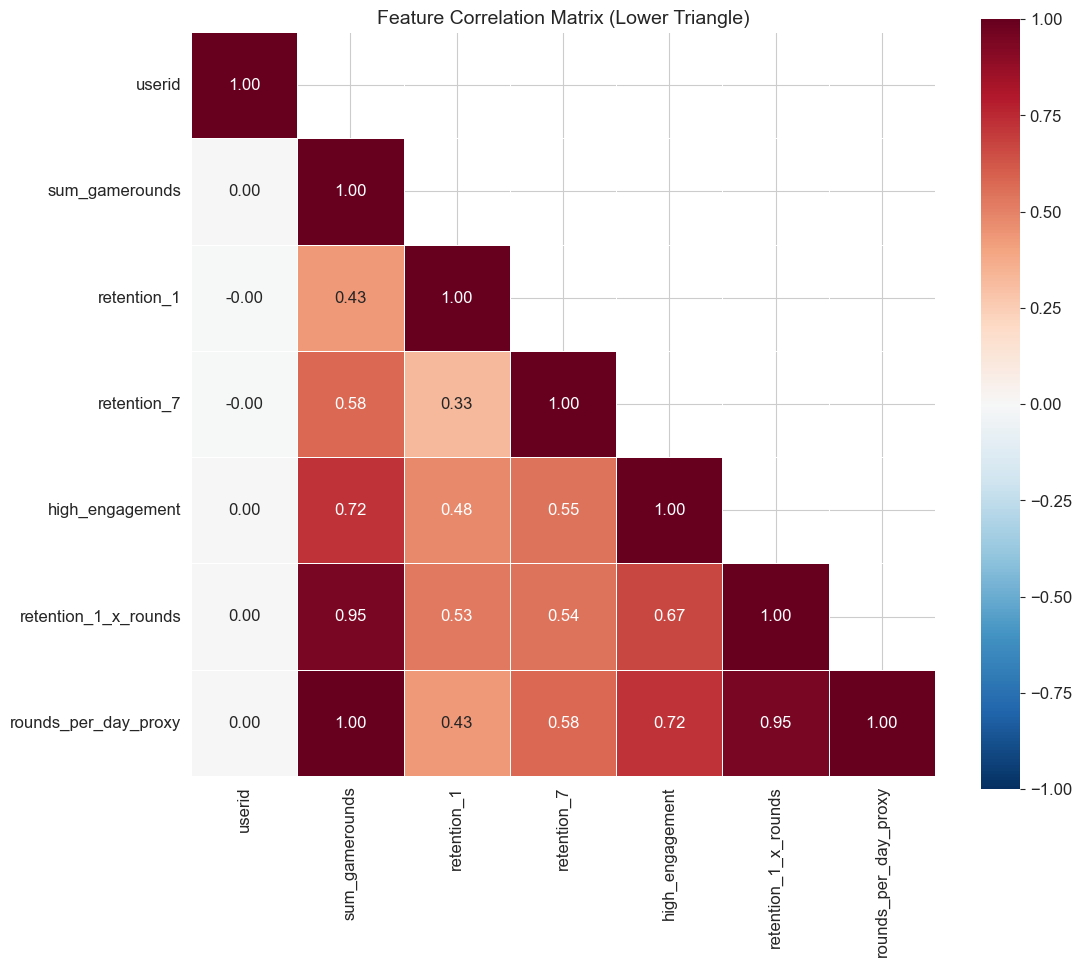

In [13]:
# ── Plot 10: Correlation Heatmap ──────────────────────────────────
numeric_df = df_feat.select_dtypes(include='number')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (Lower Triangle)')
plt.savefig('../reports/figures/eda_10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Interaction Feature: retention_1 × Game Rounds

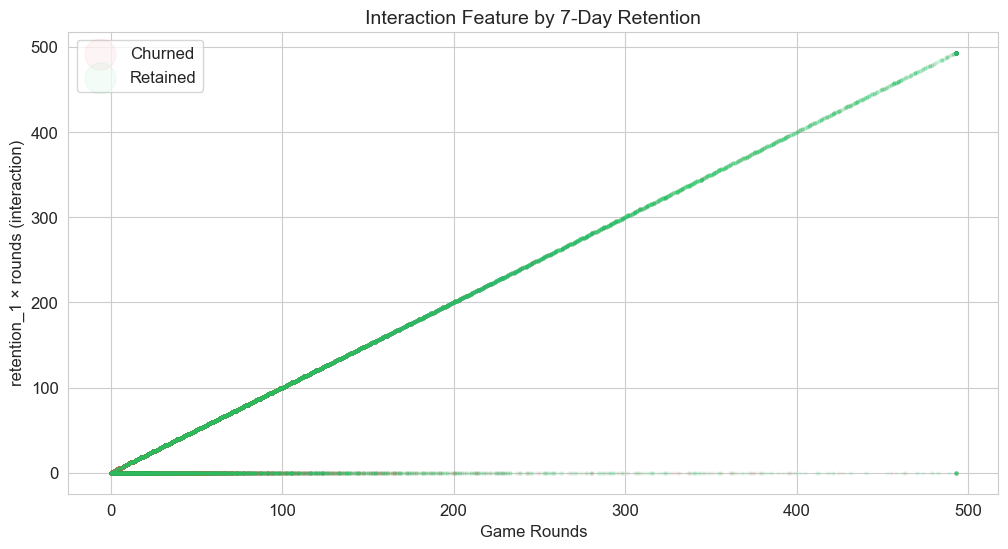

In [14]:
# ── Plot 11: Interaction Feature ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colours = {True: '#2ecc71', False: '#e74c3c', 1: '#2ecc71', 0: '#e74c3c'}
for ret_val in df_feat['retention_7'].unique():
    subset = df_feat[df_feat['retention_7'] == ret_val]
    label = 'Retained' if ret_val else 'Churned'
    ax.scatter(subset['sum_gamerounds'], subset['retention_1_x_rounds'],
               alpha=0.05, s=5, c=colours.get(ret_val, 'grey'), label=label)

ax.set_xlabel('Game Rounds')
ax.set_ylabel('retention_1 × rounds (interaction)')
ax.set_title('Interaction Feature by 7-Day Retention')
ax.legend(markerscale=10)
plt.savefig('../reports/figures/eda_11_interaction_feature.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Retention Deep Dive

### 6.1 Retention Funnel (Day 1 → Day 7)

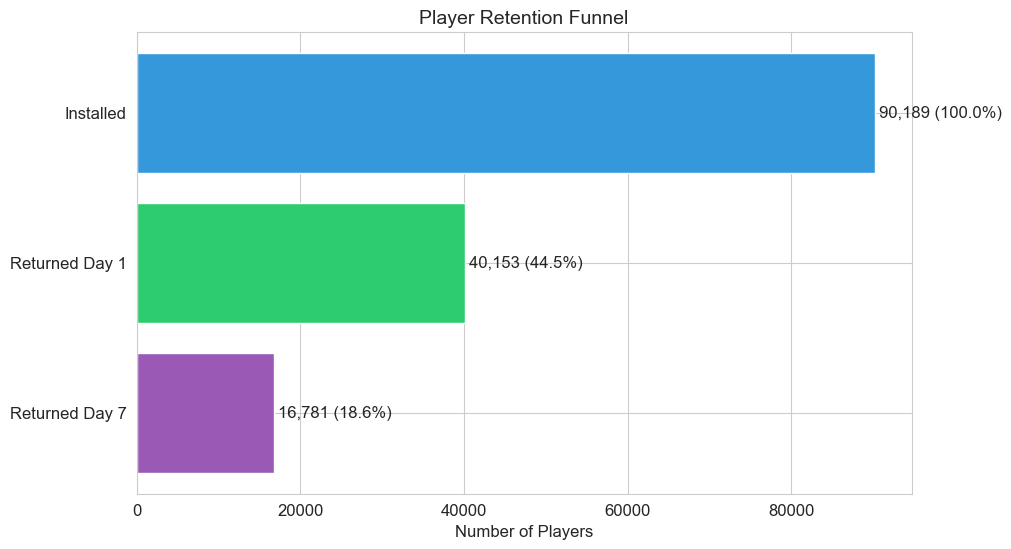

In [15]:
# ── Plot 12: Retention Funnel ─────────────────────────────────────
funnel_data = {
    'Installed': len(df_raw),
    'Returned Day 1': int(df_raw['retention_1'].sum()),
    'Returned Day 7': int(df_raw['retention_7'].sum()),
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(list(funnel_data.keys()), list(funnel_data.values()),
               color=['#3498db', '#2ecc71', '#9b59b6'], edgecolor='white')
for bar, val in zip(bars, funnel_data.values()):
    pct = val / len(df_raw) * 100
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', ha='left', va='center', fontsize=12)
ax.set_xlabel('Number of Players')
ax.set_title('Player Retention Funnel')
ax.invert_yaxis()
plt.savefig('../reports/figures/eda_12_retention_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Day 1 → Day 7 Transition Matrix

What proportion of Day-1 returnees also return on Day 7?

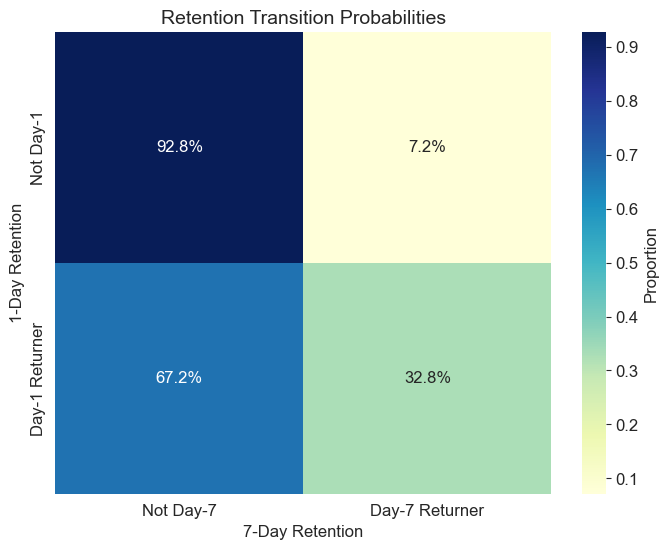

Of Day-1 returnees, 32.8% also return on Day 7


In [16]:
# ── Plot 13: Transition Matrix ────────────────────────────────────
transition = pd.crosstab(df_raw['retention_1'], df_raw['retention_7'],
                         normalize='index')
transition.index = ['Not Day-1', 'Day-1 Returner']
transition.columns = ['Not Day-7', 'Day-7 Returner']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(transition, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Proportion'})
ax.set_title('Retention Transition Probabilities')
ax.set_xlabel('7-Day Retention')
ax.set_ylabel('1-Day Retention')
plt.savefig('../reports/figures/eda_13_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
d1_and_d7 = ((df_raw['retention_1'] == True) & (df_raw['retention_7'] == True)).sum()
d1_only = (df_raw['retention_1'] == True).sum()
print(f"Of Day-1 returnees, {d1_and_d7/d1_only:.1%} also return on Day 7")

### 6.3 Retention by Game Rounds Quantile

How does play volume correlate with retention across the distribution?

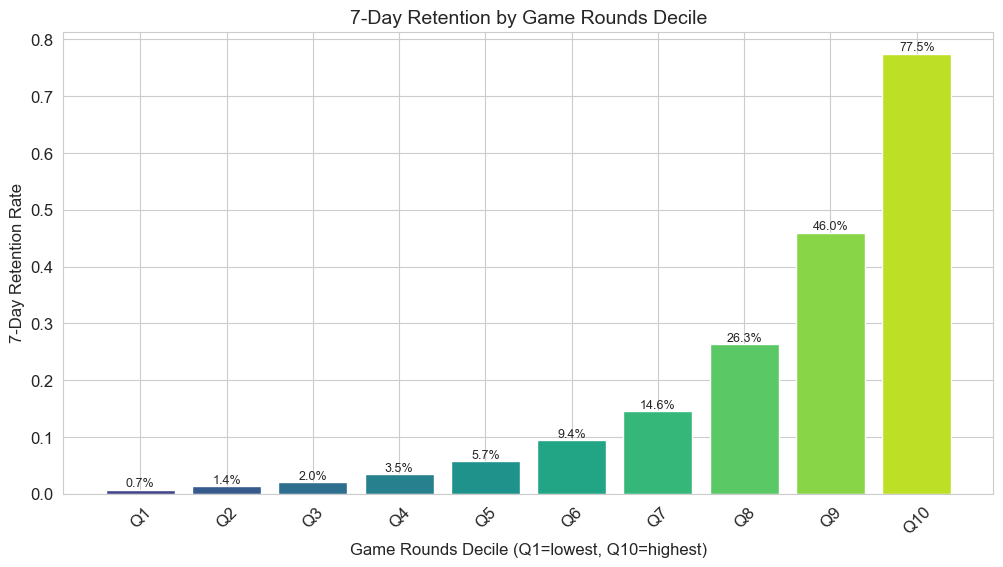

In [17]:
# ── Plot 14: Retention by Quantile ────────────────────────────────
df_raw['rounds_quantile'] = pd.qcut(df_raw['sum_gamerounds'], q=10,
                                     labels=[f'Q{i}' for i in range(1, 11)],
                                     duplicates='drop')

ret_by_q = df_raw.groupby('rounds_quantile')['retention_7'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(ret_by_q)), ret_by_q.values, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(ret_by_q))))
ax.set_xticks(range(len(ret_by_q)))
ax.set_xticklabels(ret_by_q.index, rotation=45)
ax.set_xlabel('Game Rounds Decile (Q1=lowest, Q10=highest)')
ax.set_ylabel('7-Day Retention Rate')
ax.set_title('7-Day Retention by Game Rounds Decile')
for bar, val in zip(bars, ret_by_q.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=9)
plt.savefig('../reports/figures/eda_14_retention_by_quantile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Player Segmentation

### 7.1 Zero-Round Players

Players who installed but never played (0 rounds) are a special
segment — they may indicate failed onboarding.

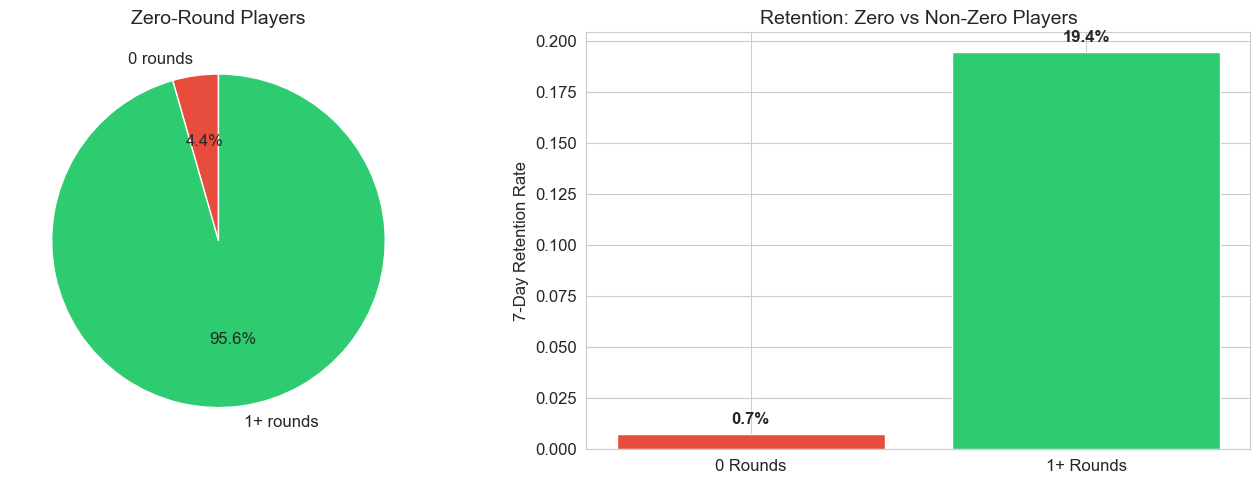

Zero-round players: 3,994 (4.4%)
Zero-round 7-day retention: 0.7%
Non-zero 7-day retention: 19.4%


In [18]:
# ── Plot 15: Zero-Round Players ───────────────────────────────────
n_zero = (df_raw['sum_gamerounds'] == 0).sum()
n_nonzero = len(df_raw) - n_zero

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proportion
axes[0].pie([n_zero, n_nonzero], labels=['0 rounds', '1+ rounds'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0].set_title('Zero-Round Players')

# Retention of zero-round players
zero_ret = df_raw[df_raw['sum_gamerounds'] == 0]['retention_7'].mean()
nonzero_ret = df_raw[df_raw['sum_gamerounds'] > 0]['retention_7'].mean()
axes[1].bar(['0 Rounds', '1+ Rounds'], [zero_ret, nonzero_ret],
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_ylabel('7-Day Retention Rate')
axes[1].set_title('Retention: Zero vs Non-Zero Players')
for i, val in enumerate([zero_ret, nonzero_ret]):
    axes[1].text(i, val + 0.005, f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/eda_15_zero_round_players.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Zero-round players: {n_zero:,} ({n_zero/len(df_raw):.1%})")
print(f"Zero-round 7-day retention: {zero_ret:.1%}")
print(f"Non-zero 7-day retention: {nonzero_ret:.1%}")

### 7.2 Combined Segment: Version × Engagement Tier × Retention

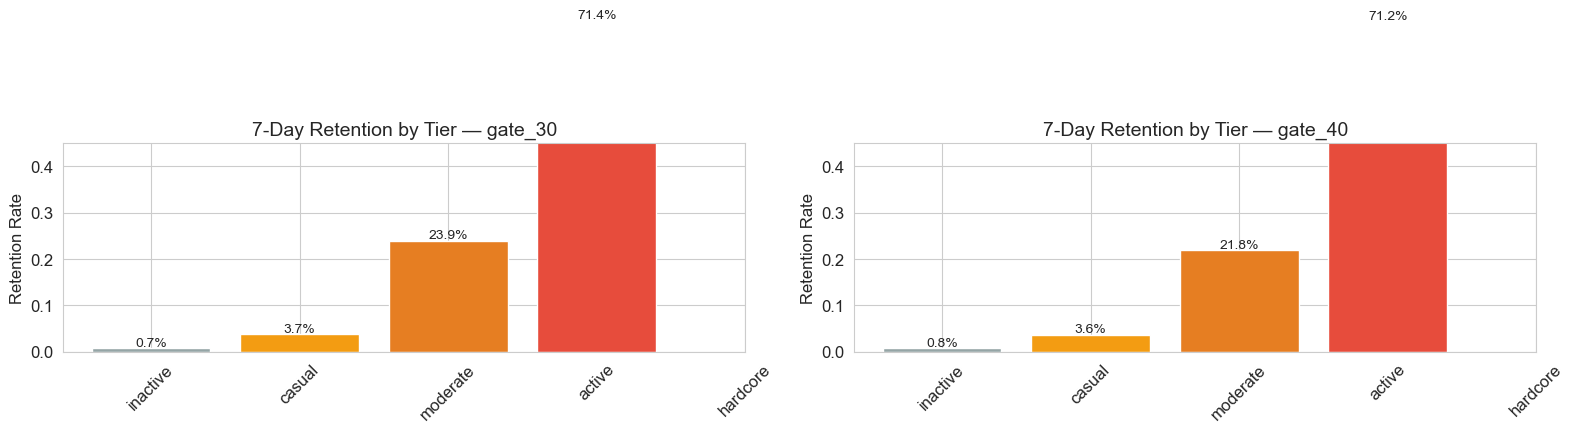

In [19]:
# ── Plot 16: Three-Way Analysis ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, version in enumerate(['gate_30', 'gate_40']):
    subset = df_feat[df_feat['version'] == version]
    pivot = subset.groupby('gamerounds_bin')['retention_7'].mean()
    bars = axes[idx].bar(range(len(pivot)), pivot.values,
                         color=['#95a5a6', '#f39c12', '#e67e22', '#e74c3c'])
    axes[idx].set_xticks(range(len(pivot)))
    axes[idx].set_xticklabels(pivot.index, rotation=45)
    axes[idx].set_title(f'7-Day Retention by Tier — {version}')
    axes[idx].set_ylabel('Retention Rate')
    axes[idx].set_ylim(0, 0.45)
    for bar, val in zip(bars, pivot.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f'{val:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/eda_16_three_way_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. EDA Summary & Key Findings

| Finding | Detail | Impact on Modelling |
|---------|--------|---------------------|
| **Heavy right skew** in game rounds | Skewness ≈ 30+, max ≈ 49,850 | Justifies 99th-percentile capping |
| **Balanced A/B groups** | ~50/50 split (44,700 vs 45,489) | Valid experimental design |
| **1-day retention ≈ 44.5%** | Nearly half return within 24h | Good initial hook |
| **7-day retention ≈ 18.6%** | Significant drop-off from day 1 | Primary target for modelling |
| **Gate 30 > Gate 40** for retention | ~0.8pp higher 7-day retention | Earlier gate benefits retention |
| **Zero-round segment** | ~3.5% of players never play | Consider excluding or flagging |
| **Strong day-1 ↔ day-7 link** | Day-1 returnees have 2× higher day-7 retention | `retention_1` is most predictive feature |
| **Chi-square significant** | p < 0.05 for version × retention | Gate version has real effect |

### Implications for Next Steps
1. **Feature engineering:** Use `retention_1`, `gamerounds_bin`, and interaction features
2. **Outlier handling:** Cap at 99th percentile (validated by IQR analysis)
3. **Class imbalance:** 7-day retention is ~19% positive — use SMOTE
4. **Model selection:** Non-linear models (RF, XGBoost) likely needed given the discrete engagement tiers